In [1]:
## parameters for experiment
N_BLOCK = 5
LR = 0.001

OUTPUT_DIR = '20260520-Stage2-MCU-Net-Residuals-CE0.95'
STAGE1_MODEL_DIR = '20260427-Stage1-MCU-Net-NewDataset'  # Directory containing pre-trained Stage-1 model

RANDOM_SEED = 42

IN_CHANNEL = 1

AUGMENTED = True
AUGMENTATION = 30

CROSS_VAL = True
N_SPLIT = 4

# residual
# 1.0 is pure stage 2 and 0 is stage 1
CONF_THRESHOLD = 0.95

In [2]:
## import libraries
import numpy
from MCtool.RFilter import gray
from genericpath import exists
from matplotlib import image
import math
import sys
import time

import cv2
from matplotlib import pyplot as plt
from tensorflow.python.keras.backend import dtype
from DeepLearning import LearnAndTest
from Rpkg.Rfund.InputFeature import InputFeature
import datetime
import os
import gc
import tensorflow as tf
import random
import numpy as np
import pandas as pd

from Rpkg.Rfund import ReadFile, WriteFile
from Rpkg.Rmodel import Unet, Mnet

import Filtering

import torch
from torch import nn

import DeepLearning
from tensorflow.keras.optimizers import Adam

from Rpkg.Rfund.InputFeature import InputFeature
from Rpkg.Rfund import ReadFile, WriteFile
from Rpkg.Rmodel import Unet, Mnet

from MCtool import RFilter, resultEval
from DeepLearning import save_eval_result

import numpy as np
import cv2
import torch
from transformations import ComposeDouble, FunctionWrapperDouble, create_dense_target, normalize_01
from customdatasets import SegmentationDataSet1
from customdatasets import SegmentationDataSet4
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import pathlib
from skimage.transform import resize

from unet import UNet
from unetNew import UNetC
from trainer import Trainer
from sklearn.model_selection import StratifiedKFold, train_test_split

I0000 00:00:1779341813.356491 2985251 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779341813.387218 2985251 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779341814.154505 2985251 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
## random seed config
import torch
import numpy as np
import random

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
## cuda and pytorch stats
print('PyTorch Version installed: ' + torch.__version__)
print('CUDA version associated with PyTorch version: ' + torch.version.cuda)
print('Version of cuDNN (CUDA Deep Neural Network library) being used by PyTorch' + str(torch.backends.cudnn.version()))
print('CUDA is available: ' + str(torch.cuda.is_available()))
print('Number of GPUs compatible with CUDA:' + str(torch.cuda.device_count()))
print('Name of the GPU at index 0: '  + str(torch.cuda.get_device_name(0)))
print('Current CUDA device index: '  + str(torch.cuda.current_device()))

PyTorch Version installed: 2.5.1+cu121
CUDA version associated with PyTorch version: 12.1
Version of cuDNN (CUDA Deep Neural Network library) being used by PyTorch90100
CUDA is available: True
Number of GPUs compatible with CUDA:1
Name of the GPU at index 0: NVIDIA GeForce RTX 4080 SUPER
Current CUDA device index: 0


In [5]:
## file_names_with_prefix
def file_names_with_prefix(directory_path, prefix):
    file_names_without_extension = []
    for filename in os.listdir(directory_path):
        if os.path.isfile(os.path.join(directory_path, filename)):
            if filename.startswith(prefix):
                name_without_extension, _ = os.path.splitext(filename)
                file_names_without_extension.append(name_without_extension)
    
    sorted_file_names = sorted(
        file_names_without_extension,
        key=lambda x: (x.split('-')[0], int(x.split('-')[1]))
    )
    return sorted_file_names

In [6]:
## paths config
import pathlib
from pathlib import Path

root_dir = Path(pathlib.Path.cwd())
date_str = OUTPUT_DIR

data_dir = str(root_dir / "img_1006t/original")
feature_dir = str(root_dir / "img_1006t/feature") 
labeled_dir = str(root_dir / "img_1006t/labeled")

augmented_labeled_dir = str(root_dir / "img_1006t/labelAug")
augmented_data_dir = str(root_dir / "img_1006t/originalAug")
augmented_feature_dir = str(root_dir / "img_1006t/featureAug")

annealing_img_dir = str(root_dir / "img_1006/original")
result_dir = str(root_dir / "result" / date_str)
test_result_dir = str(root_dir / "result_test" / date_str)

Path(result_dir).mkdir(parents=True, exist_ok=True)
Path(test_result_dir).mkdir(parents=True, exist_ok=True)

print('Root directory: ' + str(root_dir))
print('Data directory (original dir): ' + str(data_dir))
print('Feature img directory: ' + str(feature_dir))
print('Labeled img directory: ' + str(labeled_dir))
print('Result directory: ' + str(result_dir))
print('Test result directory: ' + str(test_result_dir))

input_train = []
input_name_val = []
annealing_input_name = []
test_input_name = []

len_train = len(input_train)
len_val = len(input_name_val)
len_test = len(test_input_name)
len_annealing = len(annealing_input_name)

Root directory: /home/eric/Documents/cervicalResearchIIP
Data directory (original dir): /home/eric/Documents/cervicalResearchIIP/img_1006t/original
Feature img directory: /home/eric/Documents/cervicalResearchIIP/img_1006t/feature
Labeled img directory: /home/eric/Documents/cervicalResearchIIP/img_1006t/labeled
Result directory: /home/eric/Documents/cervicalResearchIIP/result/20260520-Stage2-MCU-Net-Residuals-CE0.95
Test result directory: /home/eric/Documents/cervicalResearchIIP/result_test/20260520-Stage2-MCU-Net-Residuals-CE0.95


In [7]:
## filters
inputfeature_list = list(map(str, InputFeature))
#inputfeature_list = ['CLA_']
print(inputfeature_list)
feature_num = len(inputfeature_list)
print(feature_num)

['GRY_', 'NML1', 'NML2', 'NML3', 'TOP1', 'TOP2', 'TOP3', 'TOP4', 'SBLX', 'SBLY', 'SBLM', 'SBLD', 'SBL1', 'SBL2', 'SBL3', 'SBL4', 'LPL1', 'LPL2', 'MEA1', 'MEA2', 'GAU1', 'GAU2', 'MED1', 'MED2', 'LBP1', 'LBP2', 'LBP3', 'ETC1', 'ETC2', 'STC1', 'STC2', 'HGF_', 'NGP_', 'POS1', 'POS2', 'POS3', 'SOL_', 'EMB1', 'EMB2', 'EMB3', 'KNN1', 'KNN2', 'BLT1', 'BLT2', 'OOO_', 'CLA_']
46


In [8]:
## createweightimage read by images
def CreateWeightImage(input_number, augmentation=False):
    print("Creating image arrays...")
    label_dataset = []
    arrDataset = []
    for i in input_number:
        if augmentation:
            label_path = os.path.join(augmented_labeled_dir, str(AUGMENTATION) + "aug/" , f"{i}.png")
        else:
            label_path = os.path.join(labeled_dir, f"{i}.png")
        input_originallabel = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
        label_dataset.append(input_originallabel)

    print("Number of label images:", len(label_dataset))

    for i in input_number:
        dataset_img = np.zeros((256, 256, feature_num), dtype=np.float32)
        for m in range(feature_num):
            if augmentation:
                feature_img_path = os.path.join(augmented_feature_dir, str(AUGMENTATION) + "aug/" , str(i), f"{inputfeature_list[m]}.png")
            else:
                feature_img_path = os.path.join(feature_dir, str(i), f"{inputfeature_list[m]}.png")
            input_featureimg = cv2.imread(feature_img_path, cv2.IMREAD_GRAYSCALE)
            dataset_img[:, :, m] = input_featureimg

        arrDataset.append(dataset_img)

    arrDataset = np.array(arrDataset)
    print("Completed creating image arrays:")
    print("Dataset shape ", arrDataset.shape)
    print("Label image shape ", np.shape(label_dataset))
    print()

    return arrDataset, label_dataset

In [9]:
## createweightimagenew read paths only
def CreateWeightImageNew(input_numbers, augmentation=False):
    print("Creating image paths...")
    label_paths = []
    feature_paths = []

    for i in input_numbers:
        if augmentation:
            label_path = os.path.join(augmented_labeled_dir, str(AUGMENTATION) + "aug/", f"{i}.png")
        else:
            label_path = os.path.join(labeled_dir, f"{i}.png")
        label_paths.append(label_path)

        feature_img_paths = []
        for feature_name in inputfeature_list:
            if augmentation:
                feature_img_path = os.path.join(augmented_feature_dir, str(AUGMENTATION) + "aug/", str(i), f"{feature_name}.png")
            else:
                feature_img_path = os.path.join(feature_dir, str(i), f"{feature_name}.png")
            feature_img_paths.append(feature_img_path)

        feature_paths.append(feature_img_paths)
    print("Number of label images:", len(label_paths))
    print("Completed reading image paths")
    return feature_paths, label_paths

In [10]:
## minor irrelevant function
def print_model_shapes(model, input_tensor):
    def forward_hook(module, input, output):
        print(f"Layer: {module.__class__.__name__}")
        print(f"Input shape: {str(input[0].shape)}")
        print(f"Output shape: {str(output.shape)}")
        print("-----------------------")

    hooks = []
    for layer in model.children():
        hook = layer.register_forward_hook(forward_hook)
        hooks.append(hook)

    print("Model Architecture:")
    print(model)

    with torch.no_grad():
        model(input_tensor)

    for hook in hooks:
        hook.remove()

In [11]:
## preprocess and postprocess function
def preprocess(img: np.ndarray):
    img = np.moveaxis(img, -1, 0)
    img = normalize_01(img)
    img = np.expand_dims(img, axis=0)
    img = img.astype(np.float32)
    return img

def postprocess(img: torch.tensor):
    img = torch.argmax(img, dim = 1)
    img = img.cpu().numpy().astype(np.uint8)
    img = np.squeeze(img)
    if img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))
        img = img[:, :, ::-1]
    elif img.shape[0] == 1:
        img = np.squeeze(img, 0)
    return img

In [12]:
def record_results(training_losses, validation_losses, lr_rates, learning_curve, model, fold, input_dataset_val, input_name_val, type_number, device, model_n = "unet2"):
    
    assert len(training_losses) == len(validation_losses) == len(lr_rates), \
        "Lengths of training, validation losses, and learning rates must match."

    df = pd.DataFrame({
        "Epoch": list(range(1, len(training_losses) + 1)),
        "Training_Loss": training_losses,
        "Validation_Loss": validation_losses,
        "Learning_Rate": lr_rates
    })

    df.to_csv(test_result_dir + f"/{model_n}_fold{fold}_log.csv", index = False)
    learning_curve.savefig(test_result_dir + f"/{model_n}_fold{fold}_learningcurve.png")
    
    print("***************************")

    model_dir = os.path.join("model", date_str)
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)
    model_name = f"{model_n}_fold_{fold}.pt"
    model_path = os.path.join(model_dir, model_name)
    torch.save(model.state_dict(), model_path)
    print(f"modelname:{model_name}を保存しました")
    
    model_weights = torch.load(model_path)
    model.load_state_dict(model_weights)

In [13]:
## learn_ea function training logic - STAGE-2 ONLY with f1+f2 (109 filters)
from customdatasets import SegmentationDataSet0
from customdatasets import SegmentationDataSet1
from customdatasets import SegmentationDataSet5
from torch.utils.data import DataLoader
from skimage.io import imread
def Learn_EA(input_dataset, label_dataset, input_dataset_val, label_dataset_val, 
             type_number, fold=0, next_model=False, model_n="unet2", inChannels=57,
             stage1_model_path=None, stage1_model_loaded=None):
    """
    Stage-2 only training using pre-trained Stage-1 model.
    Generates f1 (Stage-1 probs, 11 channels) + f2 (46-filter conv on features).
    Final input: concat(f1, f2) = 11 + 46 = 57 channels
    """
    print("*************************Stage-2 Training (No Stage-1 Training)*************************")
    
    # Load pre-trained Stage-1 model if not already loaded
    if stage1_model_loaded is None and stage1_model_path is not None:
        print(f"Loading pre-trained Stage-1 model from: {stage1_model_path}")
        stage1_model = UNet(in_channels=IN_CHANNEL,
                           out_channels=11,
                           n_blocks=N_BLOCK,
                           start_filters=32,
                           activation='relu',
                           normalization='instance',
                           conv_mode='same',
                           dim=2)
        stage1_model.load_state_dict(torch.load(stage1_model_path))
        stage1_model_loaded = stage1_model
    
    if stage1_model_loaded is None:
        raise ValueError("stage1_model_path or stage1_model_loaded must be provided")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Get Stage-1 outputs (f1) and 46-filter outputs (f2) for training data
    print("\nGenerating f1 (Stage-1 probs) and f2 (46-filter tensor) for training data...")
    stage1_model_loaded.eval()
    stage1_model_loaded.to(device)
    
    stage1_train_f1 = []
    stage1_train_f2 = []
    with torch.no_grad():
        for idx, img in enumerate(input_dataset):
            img_preprocessed = preprocess(img)  # [1, 46, 256, 256]
            img_tensor = torch.from_numpy(img_preprocessed).to(device)
            
            # f1: Stage-1 UNet output (11 channels) - use only first channel
            # Training data — add softmax:
            output_f1 = stage1_model_loaded(img_tensor[:, -1:, :, :])
            output_f1_prob = torch.softmax(output_f1, dim=1)  # ADD THIS
            stage1_train_f1.append(output_f1_prob.squeeze(0).cpu().numpy())  # use prob not output_f1
            
            # f2: 46-filter convolution on all 46 channels (46 channels)
            output_f2 = img_tensor  # [1, 46, 256, 256]
            stage1_train_f2.append(output_f2.squeeze(0).cpu().numpy())
    
    stage1_train_f1 = np.array(stage1_train_f1)  # [N, 11, 256, 256]
    stage1_train_f2 = np.array(stage1_train_f2)  # [N, 46, 256, 256]
    
    # Concatenate f1 + f2 (11 + 46 = 57 channels)
    stage1_train_outputs = np.concatenate((stage1_train_f1, stage1_train_f2), axis=1)  # [N, 57, 256, 256]
    print(f"f1 training shape: {stage1_train_f1.shape}")
    print(f"f2 training shape: {stage1_train_f2.shape}")
    print(f"Concatenated training shape: {stage1_train_outputs.shape}")
    
    # Get Stage-1 outputs (f1) and 46-filter outputs (f2) for validation data
    print("Generating f1 and f2 for validation data...")
    stage1_val_f1 = []
    stage1_val_f2 = []
    
    
    with torch.no_grad():
        for idx, img in enumerate(input_dataset_val):
            img_preprocessed = preprocess(img)
            img_tensor = torch.from_numpy(img_preprocessed).to(device)
            
            # f1: Stage-1 UNet output (11 channels) - use only first channel
            output_f1 = stage1_model_loaded(img_tensor[:, -1:, :, :])
            output_f1_prob = torch.softmax(output_f1, dim=1)  # ADD THIS
            stage1_val_f1.append(output_f1_prob.squeeze(0).cpu().numpy())
            
            # f2: 46-filter convolution on all 46 channels (46 channels)
            output_f2 = img_tensor  # [1, 46, 256, 256]
            stage1_val_f2.append(output_f2.squeeze(0).cpu().numpy())
    
    stage1_val_f1 = np.array(stage1_val_f1)  # [M, 11, 256, 256]
    stage1_val_f2 = np.array(stage1_val_f2)  # [M, 46, 256, 256]
    
    # Concatenate f1 + f2 (11 + 46 = 57 channels)
    stage1_val_outputs = np.concatenate((stage1_val_f1, stage1_val_f2), axis=1)  # [M, 57, 256, 256]
    print(f"f1 validation shape: {stage1_val_f1.shape}")
    print(f"f2 validation shape: {stage1_val_f2.shape}")
    print(f"Concatenated validation shape: {stage1_val_outputs.shape}")
    
    # Create datasets from concatenated f1+f2 for Stage-2 training
    print("\n--- Creating Stage-2 DataLoaders ---")
    dataset_train2 = SegmentationDataSet0(
        inputs=stage1_train_outputs,
        targets=label_dataset,
        transform=None
    )

    dataset_val = SegmentationDataSet0(
        inputs=stage1_val_outputs,
        targets=label_dataset_val,
        transform=None
    )

    dataloader_training2 = DataLoader(dataset=dataset_train2,
                                        batch_size=2,
                                        shuffle=True)
    
    dataloader_val = DataLoader(dataset=dataset_val,
                                batch_size=2,
                                shuffle=False)
    
    batch = next(iter(dataloader_training2))
    x, y = batch
    print("Stage-2 batch shapes - x: ", x.shape)
    print("Stage-2 batch shapes - y: ", y.shape)
    print("x.min(), x.max() = ", x.min(), x.max())
    print("torch.unique(y) = ", torch.unique(y))

    # Stage-2 UNet training
    from unet import UNet
    from trainer2 import Trainer2 
    from customLoss import DiceLoss
    from customLoss import TverskyCELoss
    from customLoss import DiceCELoss
    from customLoss import FocalLoss
    from customLoss import DiceLoss

    model = UNetC(in_channels=inChannels,
                 out_channels=11,
                 n_blocks=N_BLOCK, 
                 start_filters=32,
                 activation='relu',
                 normalization='instance',
                 conv_mode='same',
                 dim=2).to(device)
    
    criterion = torch.nn.CrossEntropyLoss()
    
    # criterion = TverskyCELoss(
    # ce_weight=0.5,
    # tversky_weight=0.5,
    # alpha=0.3,
    # beta=0.7
    # ).to(device)
    #criterion = DiceLoss()
    #criterion = DiceCELoss(dice_weight=0.5, ce_weight=0.5)
    #criterion = FocalLoss(gamma=2.0)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    print("\n--- Starting Stage-2 Training ---")
    trainer = Trainer2(model=model, 
                       device=device, 
                       criterion=criterion, 
                       optimizer=optimizer, 
                       training_DataLoader=dataloader_training2,
                       validation_DataLoader=dataloader_val, 
                       lr_scheduler=None, 
                       epochs=200,
                       fold=fold,
                       notebook=True)
  
    print("=======Starting Stage-2 Training======")
    training_losses, validation_losses, lr_rates, learning_curve, train_preds, train_targets, val_preds, val_targets = trainer.run_trainer()
    
    def safe_cat(tensors):
        if isinstance(tensors, torch.Tensor):
            return tensors
        if len(tensors) == 0:
            raise RuntimeError("No predictions collected.")
        return torch.cat(tensors, dim=0)

    train_preds = safe_cat(train_preds)
    train_targets = safe_cat(train_targets)
    val_preds = safe_cat(val_preds)
    val_targets = safe_cat(val_targets)

    record_results(training_losses, validation_losses, lr_rates, learning_curve, model, fold, 
                   stage1_val_outputs, input_name_val, type_number, device, model_n)
    
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    
    print("\n=======Stage-2 Training Complete======\n")

In [14]:
## dice calculation
import statistics

def cal_DiceMulitple(dir, input_name):
    Dice = [0] * 11
    Count1 = [0] * 11
    Count2 = [0] * 11
    Count3 = [0] * 11
    
    for index in range(len(input_name)):
        print('index = ', index)

        img1 = cv2.imread(dir + '/' + input_name[index] + ".png", cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(labeled_dir + '/' + input_name[index] + ".png", cv2.IMREAD_GRAYSCALE)
        print("予測画像:", dir  + '/' + input_name[index] + ".png")
        print("テストラベル:", labeled_dir + '/' + input_name[index] + ".png")
        unique_label1 = np.unique(img1)
        unique_label2 = np.unique(img2)
        
        for n in range(256):
            for l in range(256):
                value1 = img1[n,l]
                Count1[value1] += 1
                value2 = img2[n,l]
                Count2[value2] += 1                    
                if(value1 == value2):
                    Count3[value1] += 1 
    
    for i in range(11):
        if(Count1[i]+Count2[i] != 0):
            Dice[i] = (2*Count3[i])/(Count1[i] + Count2[i])
    
    Dice.append(statistics.mean(Dice[1:]))
    print('Count1 = ', Count1)
    print('Count2 = ', Count2)
    print('Count3 = ', Count3)
    print('Dice = ', Dice)

    return Dice

In [15]:
from scipy import ndimage
from scipy.spatial.distance import cdist
import numpy as np
import cv2
import statistics

def cal_HD95_Multiple(dir, input_name, num_classes=11):
    HD95 = [0] * num_classes
    counts = [0] * num_classes

    for index in range(len(input_name)):
        print('index = ', index)
        img1 = cv2.imread(dir + '/' + input_name[index] + ".png", cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(labeled_dir + '/' + input_name[index] + ".png", cv2.IMREAD_GRAYSCALE)

        for c in range(1, num_classes):
            pred_c   = (img1 == c).astype(np.uint8)
            target_c = (img2 == c).astype(np.uint8)

            # Skip if absent in both
            if pred_c.sum() == 0 and target_c.sum() == 0:
                continue

            # Max penalty if absent in one
            if pred_c.sum() == 0 or target_c.sum() == 0:
                HD95[c] += np.sqrt(img1.shape[0]**2 + img1.shape[1]**2)
                counts[c] += 1
                continue

            pred_points   = np.argwhere(pred_c)
            target_points = np.argwhere(target_c)

            distances     = cdist(pred_points, target_points)
            d_pred_target = distances.min(axis=1)
            d_target_pred = distances.min(axis=0)
            all_distances = np.concatenate([d_pred_target, d_target_pred])

            HD95[c] += np.percentile(all_distances, 95)
            counts[c] += 1

    # Average per class
    for c in range(1, num_classes):
        if counts[c] > 0:
            HD95[c] = HD95[c] / counts[c]

    HD95.append(statistics.mean([HD95[c] for c in range(1, num_classes) if counts[c] > 0]))
    print('HD95 = ', HD95)
    return HD95


def cal_ASD_Multiple(dir, input_name, num_classes=11):
    ASD = [0] * num_classes
    counts = [0] * num_classes

    for index in range(len(input_name)):
        print('index = ', index)
        img1 = cv2.imread(dir + '/' + input_name[index] + ".png", cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(labeled_dir + '/' + input_name[index] + ".png", cv2.IMREAD_GRAYSCALE)

        for c in range(1, num_classes):
            pred_c   = (img1 == c).astype(np.uint8)
            target_c = (img2 == c).astype(np.uint8)

            if pred_c.sum() == 0 and target_c.sum() == 0:
                continue

            if pred_c.sum() == 0 or target_c.sum() == 0:
                ASD[c] += np.sqrt(img1.shape[0]**2 + img1.shape[1]**2)
                counts[c] += 1
                continue

            pred_points   = np.argwhere(pred_c)
            target_points = np.argwhere(target_c)

            distances     = cdist(pred_points, target_points)
            d_pred_target = distances.min(axis=1).mean()  # mean instead of percentile
            d_target_pred = distances.min(axis=0).mean()

            ASD[c] += (d_pred_target + d_target_pred) / 2.0
            counts[c] += 1

    for c in range(1, num_classes):
        if counts[c] > 0:
            ASD[c] = ASD[c] / counts[c]

    ASD.append(statistics.mean([ASD[c] for c in range(1, num_classes) if counts[c] > 0]))
    print('ASD = ', ASD)
    return ASD


def cal_CCD_Multiple(dir, input_name, num_classes=11):
    """Connected Component Count — measures fragmentation"""
    CCD = [0] * num_classes
    counts = [0] * num_classes

    for index in range(len(input_name)):
        print('index = ', index)
        img1 = cv2.imread(dir + '/' + input_name[index] + ".png", cv2.IMREAD_GRAYSCALE)

        for c in range(1, num_classes):
            pred_c = (img1 == c).astype(np.uint8)

            if pred_c.sum() == 0:
                continue

            _, n_components = ndimage.label(pred_c)
            CCD[c] += n_components
            counts[c] += 1

    for c in range(1, num_classes):
        if counts[c] > 0:
            CCD[c] = CCD[c] / counts[c]

    CCD.append(statistics.mean([CCD[c] for c in range(1, num_classes) if counts[c] > 0]))
    print('CCD = ', CCD)
    return CCD

In [16]:
## mConv_predict test function
import statistics
from inference import predict
from denseCRF import noiseReduction

def mConv_predict(test_input_name, fold=0, stage1_model_path=None):
    print("*************************************Test*************************************")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ---------- Load Models ----------
    model_dir = os.path.join("model", date_str)
    model2_path = os.path.join(model_dir, f"unet2_fold_{fold}.pt")
    
    if stage1_model_path is None:
        model1_path = os.path.join(model_dir, f"unet1_fold_{fold}.pt")
    else:
        model1_path = stage1_model_path

    # Load Stage-1 model
    stage1_model = UNet(in_channels=IN_CHANNEL,
            out_channels=11,
            n_blocks=N_BLOCK,
            start_filters=32,
            activation='relu',
            normalization='instance',
            conv_mode='same',
            dim=2).to(device)
    stage1_model.load_state_dict(torch.load(model1_path))
    stage1_model.eval()

    
    
    model2 = UNetC(in_channels=57,
            out_channels=11,
            n_blocks=N_BLOCK,
            start_filters=32,
            activation='relu',
            normalization='instance',
            conv_mode='same',
            dim=2).to(device)

    model2.load_state_dict(torch.load(model2_path))
    model2.eval()

    # ---------- Load Test ----------
    test_input_dataset, _ = CreateWeightImage(test_input_name)

    output_stage2 = []
    
    
    #######
    ##confidence swapping heatmap purpose
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import LinearSegmentedColormap

    def normalize_confidence(conf, threshold=0.95):
        """Normalize confidence symmetrically around threshold"""
        normalized = torch.where(
            conf >= threshold,
            0.5 + 0.5 * (conf - threshold) / (1.0 - threshold + 1e-6),
            0.5 * conf / (threshold + 1e-6)
        )
        return normalized
    def visualize_confidence_gating(test_input_dataset, test_input_name,
                                 stage1_model, model2, device,
                                 labeled_dir, CONF_THRESHOLD=0.95,
                                 n_samples=5, save_dir='figures'):
    
        os.makedirs(save_dir, exist_ok=True)
        
        # Custom balanced colormap — blue(cold) → white(threshold) → red(warm)
        cmap = LinearSegmentedColormap.from_list(
            'confidence', 
            ['#2166ac', '#92c5de', '#f7f7f7', '#f4a582', '#d6604d'],
            N=256
        )
    sample_count = 10
    save_dir_heatmap = "/home/eric/Documents/cervicalResearchIIP/result_test/heatmap"
    ######
    
    
    # ---------- Generate f1 + f2 and Stage-2 ----------
    with torch.no_grad():
        for idx, img in enumerate(test_input_dataset):
            
            name = test_input_name[idx]
            
            img_preprocessed = preprocess(img)
            img_tensor = torch.from_numpy(img_preprocessed).to(device)
            
            # Stage 1 — correct channel, softmax once
            output_f1_logits = stage1_model(img_tensor[:, -1:, :, :])
            s1_soft = torch.softmax(output_f1_logits, dim=1)  # once only
            
            # Concat for Stage 2 — use s1_soft
            concat_input = torch.cat((s1_soft, img_tensor), dim=1)  # [1, 57, H, W]
            
            # Stage 2
            out2 = model2(concat_input)
            s2_hard = torch.argmax(out2, 1).squeeze()
            
            # Confidence gating
            confidence = torch.max(s1_soft, dim=1).values.squeeze()
            pred_s1 = torch.argmax(s1_soft, dim=1).squeeze().clone()
            uncertain_mask = confidence < CONF_THRESHOLD
            pred_final = pred_s1.clone()
            pred_final[uncertain_mask] = s2_hard[uncertain_mask]
            
            output_stage2.append(pred_final.cpu().numpy())
            
            
            #####visualization heatmap####
            # Normalize confidence symmetrically around threshold
            conf_normalized = normalize_confidence(confidence, CONF_THRESHOLD)
            
            # Load raw image and label
            raw_img = img_tensor[0, -1, :, :].cpu().numpy()  # CLAHE channel
            label = cv2.imread(
                os.path.join(labeled_dir, f"{name}.png"),
                cv2.IMREAD_GRAYSCALE
            )
            
            # Convert to numpy
            conf_np       = conf_normalized.cpu().numpy()
            pred_s1_np    = pred_s1.cpu().numpy()
            pred_final_np = pred_final.cpu().numpy()
            switching_map = uncertain_mask.cpu().numpy()  # True = Stage 2 used
            
            # Plot
            fig = plt.figure(figsize=(18, 4))
            gs  = gridspec.GridSpec(1, 5, figure=fig)
            
            # 1. Raw CLAHE image
            ax1 = fig.add_subplot(gs[0])
            ax1.imshow(raw_img, cmap='gray')
            ax1.set_title('Input (CLAHE)')
            ax1.axis('off')
            
            # 2. Stage 1 prediction
            ax2 = fig.add_subplot(gs[1])
            ax2.imshow(pred_s1_np, cmap='tab20')
            ax2.set_title('Stage 1 Prediction')
            ax2.axis('off')
            
            # 3. Confidence heatmap — balanced around threshold
            ax3 = fig.add_subplot(gs[2])
            im = ax3.imshow(conf_np, cmap="viridis", vmin=0, vmax=1)
            ax3.set_title(f'Confidence Map\n(threshold={CONF_THRESHOLD})')
            ax3.axis('off')
            cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
            cbar.set_ticks([0, 0.5, 1.0])
            cbar.set_ticklabels(['Low', f'Threshold\n({CONF_THRESHOLD})', 'High'])
            
            # 4. Switching map — binary where Stage 2 was used
            ax4 = fig.add_subplot(gs[3])
            ax4.imshow(switching_map, cmap='RdBu', vmin=0, vmax=1)
            ax4.set_title('Switching Map\n(blue=S1, red=S2)')
            ax4.axis('off')
            
            # 5. Final prediction
            ax5 = fig.add_subplot(gs[4])
            ax5.imshow(pred_final_np, cmap='tab20')
            ax5.set_title('Final Prediction')
            ax5.axis('off')
            
            plt.suptitle(f'Sample: {name}', fontsize=12)
            plt.tight_layout()
            plt.savefig(os.path.join(save_dir_heatmap, f'confidence_gate_{name}.png'), 
                       dpi=150, bbox_inches='tight')
            plt.close()
            
            print(f"Saved: {name} | "
                  f"Uncertain pixels: {switching_map.sum()} "
                  f"({switching_map.mean()*100:.1f}%)")
            
            sample_count += 1
            #####visualization heatmap####


    # ---------- Save results ----------
    fold_dir = os.path.join(test_result_dir, f"fold{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    unet2_dir = os.path.join(fold_dir, "unet2")
    os.makedirs(unet2_dir, exist_ok=True)

    for i, name in enumerate(test_input_name):
        cv2.imwrite(os.path.join(unet2_dir, f"{name}.png"), output_stage2[i])

    # evaluation part
    
    # ---------- Dice + CRF ----------
    Dice2 = cal_DiceMulitple(unet2_dir, test_input_name)
    pd.DataFrame(Dice2).T.to_csv(f"{test_result_dir}/unet2Dice.csv", mode='a', header=False)

    postCRF2 = noiseReduction(output_stage2, test_input_name, labeled_dir, unet2_dir, 0.8)

    DiceCRF2 = cal_DiceMulitple(unet2_dir + "/crf", test_input_name)
    pd.DataFrame(DiceCRF2).T.to_csv(f"{test_result_dir}/unet2CRFDice.csv", mode='a', header=False)
    
    
    #new evaluations
    HD95_2 = cal_HD95_Multiple(unet2_dir, test_input_name)
    pd.DataFrame(HD95_2).T.to_csv(f"{test_result_dir}/unet2HD95.csv", mode='a', header=False)

    ASD_2 = cal_ASD_Multiple(unet2_dir, test_input_name)
    pd.DataFrame(ASD_2).T.to_csv(f"{test_result_dir}/unet2ASD.csv", mode='a', header=False)

    CCD_2 = cal_CCD_Multiple(unet2_dir, test_input_name)
    pd.DataFrame(CCD_2).T.to_csv(f"{test_result_dir}/unet2CCD.csv", mode='a', header=False)

    # Same for CRF results:
    HD95_CRF2 = cal_HD95_Multiple(unet2_dir + "/crf", test_input_name)
    pd.DataFrame(HD95_CRF2).T.to_csv(f"{test_result_dir}/unet2CRFHD95.csv", mode='a', header=False)

    ASD_CRF2 = cal_ASD_Multiple(unet2_dir + "/crf", test_input_name)
    pd.DataFrame(ASD_CRF2).T.to_csv(f"{test_result_dir}/unet2CRFASD.csv", mode='a', header=False)

    CCD_CRF2 = cal_CCD_Multiple(unet2_dir + "/crf", test_input_name)
    pd.DataFrame(CCD_CRF2).T.to_csv(f"{test_result_dir}/unet2CRFCCD.csv", mode='a', header=False)
    
    
    

STAGE-2 ONLY: Loading Pre-Trained Stage-1 Model
['N1-1' 'N1-2' 'N1-3' 'N1-4' 'N1-5' 'N1-6' 'N1-7' 'N1-8' 'N1-9' 'N1-10'
 'N2-1' 'N2-2' 'N2-3' 'N2-4' 'N2-5' 'N2-6' 'N2-7' 'N2-8' 'N2-9' 'N2-10'
 'N3-1' 'N3-2' 'N3-3' 'N3-4' 'N3-5' 'N3-6' 'N3-7' 'N3-8' 'N3-9' 'N3-10'
 'N4-1' 'N4-2' 'N4-3' 'N4-4' 'N4-5' 'N4-6' 'N4-7' 'N4-8' 'N4-9' 'N5-1'
 'N5-2' 'N5-3' 'N5-4' 'N5-5' 'N5-6' 'N6-1' 'N6-2' 'N6-3' 'N6-4' 'N6-5'
 'N6-6' 'N6-7' 'N6-8' 'N6-9' 'N6-10' 'N6-11']
['N1' 'N1' 'N1' 'N1' 'N1' 'N1' 'N1' 'N1' 'N1' 'N1' 'N2' 'N2' 'N2' 'N2'
 'N2' 'N2' 'N2' 'N2' 'N2' 'N2' 'N3' 'N3' 'N3' 'N3' 'N3' 'N3' 'N3' 'N3'
 'N3' 'N3' 'N4' 'N4' 'N4' 'N4' 'N4' 'N4' 'N4' 'N4' 'N4' 'N5' 'N5' 'N5'
 'N5' 'N5' 'N5' 'N6' 'N6' 'N6' 'N6' 'N6' 'N6' 'N6' 'N6' 'N6' 'N6' 'N6']
Pre-trained Stage-1 model path: model/20260427-Stage1-MCU-Net-NewDataset/unet1_fold_1.pt
Loading Stage-1 model...
in constructor inchannel: 1
Input channel count9
✓ Stage-1 model loaded successfully
Cross validation: True
Fold: 1 out of 4
Augmentation: True
Augme

/tmp/ipykernel_2985251/2446803106.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stage1_model.load_state_dict(torch.load(stage1_model_path))


Number of label images: 240
Completed creating image arrays:
Dataset shape  (240, 256, 256, 46)
Label image shape  (240, 256, 256)

Creating image arrays...
Number of label images: 330
Completed creating image arrays:
Dataset shape  (330, 256, 256, 46)
Label image shape  (330, 256, 256)

*************************Stage-2 Training (No Stage-1 Training)*************************

Generating f1 (Stage-1 probs) and f2 (46-filter tensor) for training data...
f1 training shape: (240, 11, 256, 256)
f2 training shape: (240, 46, 256, 256)
Concatenated training shape: (240, 57, 256, 256)
Generating f1 and f2 for validation data...
f1 validation shape: (330, 11, 256, 256)
f2 validation shape: (330, 46, 256, 256)
Concatenated validation shape: (330, 57, 256, 256)

--- Creating Stage-2 DataLoaders ---
Stage-2 batch shapes - x:  torch.Size([2, 57, 256, 256])
Stage-2 batch shapes - y:  torch.Size([2, 256, 256])
x.min(), x.max() =  tensor(0.) tensor(1.)
torch.unique(y) =  tensor([ 0,  1,  2,  3,  4,  5,

Progress:   0%|          | 0/200 [00:00<?, ?it/s]

Training:   0%|          | 0/120 [00:00<?, ?it/s]

...

train_losses 0.01029237019829452
val_losses 0.5658277341813752
lr 0.00011282978723404247
EarlyStopping counter: 50 out of 50
early stopping epoch: 67
***************************
modelname:unet2_fold_4.ptを保存しました


/tmp/ipykernel_2985251/3649052593.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(model_path)



=======Stage-2 Training Complete======

*************************************Test*************************************
in constructor inchannel: 1
Input channel count9
in constructor inchannel: 57
Input channel count3
Creating image arrays...
Number of label images: 14


/tmp/ipykernel_2985251/2324182097.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stage1_model.load_state_dict(torch.load(model1_path))
/tmp/ipykernel_2985251/232418209

Completed creating image arrays:
Dataset shape  (14, 256, 256, 46)
Label image shape  (14, 256, 256)

Saved: N1-1 | Uncertain pixels: 1167 (1.8%)
Saved: N1-7 | Uncertain pixels: 1085 (1.7%)
Saved: N2-3 | Uncertain pixels: 1670 (2.5%)
Saved: N2-7 | Uncertain pixels: 952 (1.5%)
Saved: N2-8 | Uncertain pixels: 967 (1.5%)
Saved: N3-1 | Uncertain pixels: 932 (1.4%)
Saved: N3-5 | Uncertain pixels: 818 (1.2%)
Saved: N4-2 | Uncertain pixels: 1063 (1.6%)
Saved: N4-5 | Uncertain pixels: 895 (1.4%)
Saved: N5-2 | Uncertain pixels: 2855 (4.4%)
Saved: N5-4 | Uncertain pixels: 1884 (2.9%)
Saved: N6-2 | Uncertain pixels: 632 (1.0%)
Saved: N6-3 | Uncertain pixels: 1180 (1.8%)
Saved: N6-6 | Uncertain pixels: 442 (0.7%)
index =  0
予測画像: /home/eric/Documents/cervicalResearchIIP/result_test/20260520-Stage2-MCU-Net-Residuals-CE0.95/fold4/unet2/N1-1.png
テストラベル: /home/eric/Documents/cervicalResearchIIP/img_1006t/labeled/N1-1.png
index =  1
予測画像: /home/eric/Documents/cervicalResearchIIP/result_test/20260520-St

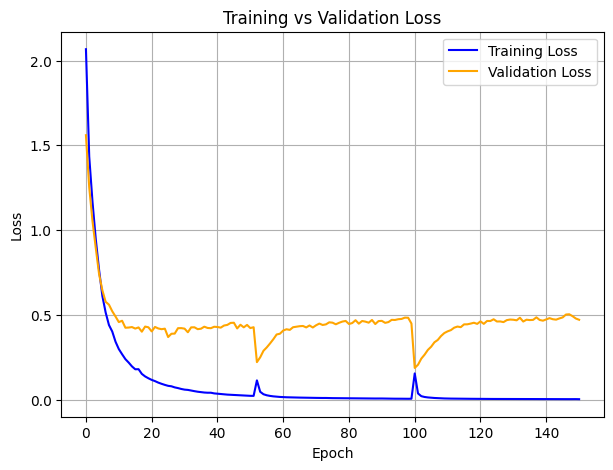

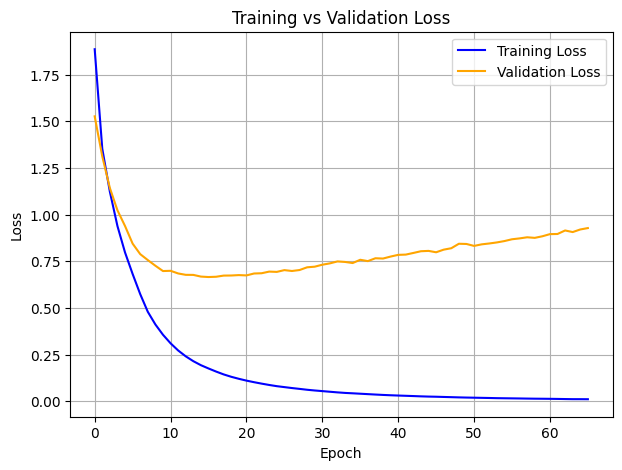

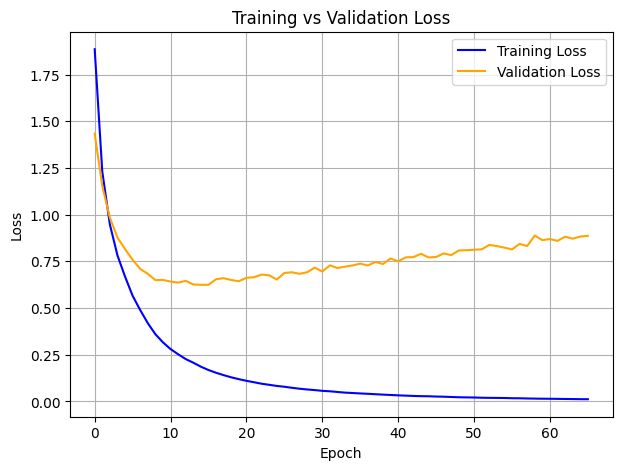

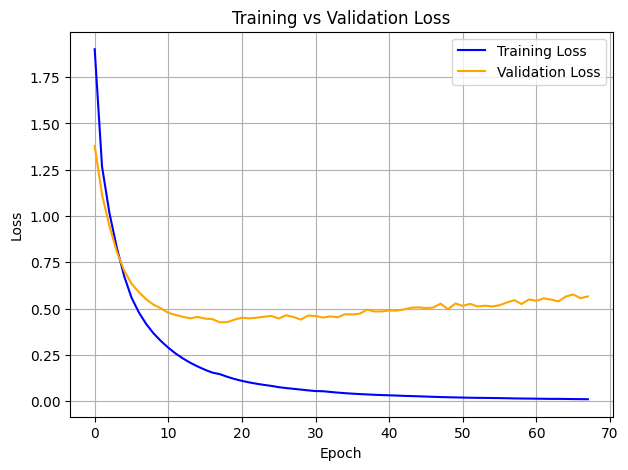

In [17]:
## Execution - STAGE-2 ONLY (Load pre-trained Stage-1)
from dataArrange import dataRearrange1

print("="*60)
print("STAGE-2 ONLY: Loading Pre-Trained Stage-1 Model")
print("="*60)

#stage1_model = None
# Prepare data splits
random_seed = 0
X = file_names_with_prefix(data_dir, 'N')
y_file_names = file_names_with_prefix(labeled_dir, 'N')
y = [label_group[:2] for label_group in y_file_names]

X = np.array(X)
y = np.array(y)

print(X)
print(y)

# Training transformations
transforms_training = ComposeDouble([
    FunctionWrapperDouble(create_dense_target, input=False, target=True),
    FunctionWrapperDouble(np.moveaxis, input=True, target=False, source=-1, destination=0),
    FunctionWrapperDouble(normalize_01)
])

transforms_val = ComposeDouble([
    FunctionWrapperDouble(create_dense_target, input=False, target=True),
    FunctionWrapperDouble(np.moveaxis, input=True, target=False, source=-1, destination=0),
    FunctionWrapperDouble(normalize_01)
])

if CROSS_VAL:
    skf = StratifiedKFold(n_splits=N_SPLIT, shuffle=True)
    for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
        
        # Load pre-trained Stage-1 model
        model_dir_stage1 = os.path.join("model", STAGE1_MODEL_DIR)
        stage1_model_path = os.path.join(model_dir_stage1, f"unet1_fold_{fold}.pt")
        print(f"Pre-trained Stage-1 model path: {stage1_model_path}")
        if not os.path.exists(stage1_model_path):
            print(f"ERROR: Stage-1 model not found at {stage1_model_path}")
            raise FileNotFoundError(f"Stage-1 model not found: {stage1_model_path}")

        # Load Stage-1 model once
        print("Loading Stage-1 model...")
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        stage1_model = UNet(in_channels=IN_CHANNEL,
                        out_channels=11,
                        n_blocks=N_BLOCK,
                        start_filters=32,
                        activation='relu',
                        normalization='instance',
                        conv_mode='same',
                        dim=2).to(device)
        stage1_model.load_state_dict(torch.load(stage1_model_path))
        print("✓ Stage-1 model loaded successfully")



        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        X_train_final, X_val, y_train_final, y_val = train_test_split(
            X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)
        
        stage1_train, stage2_train, stage1_train_y, stage2_train_y = train_test_split(
            X_train_final, y_train_final,
            test_size=0.25,
            random_state=42,
            stratify=y_train_final
        )
        
        input_train = stage2_train
        input_name_val = X_val
        
        print("Cross validation: " + str(CROSS_VAL))
        print(f"Fold: {fold} out of {N_SPLIT}")
        print("Augmentation: " + str(AUGMENTED))
        if AUGMENTED:
            print("Augmentation amount: " + str(AUGMENTATION))
        
        print("Training Stage 1: Total of " + str(len(stage1_train)) + " cases.")
        print(stage1_train)
        
        print("Training Stage 2: Total of " + str(len(stage2_train)) + " cases.")
        print(stage2_train)
        
        print("Validation: Total of " + str(len(input_name_val)) + " cases.")
        print(input_name_val)
        print("Test: Total of " + str(len(X_test)) + " cases.")  
        print(X_test)
        print()
        
        if AUGMENTED:
            repeated_items_train = np.repeat(input_train, AUGMENTATION)
            suffixes_train = np.tile(np.arange(1, AUGMENTATION + 1), len(repeated_items_train))
            input_train = np.array([f"{item}-{suffix}" for item, suffix in zip(repeated_items_train, suffixes_train)])
            input_train = np.array(dataRearrange1(input_train, AUGMENTATION))
            
            repeated_items_val = np.repeat(input_name_val, AUGMENTATION)
            suffixes_val = np.tile(np.arange(1, AUGMENTATION + 1), len(repeated_items_val))
            input_name_val = np.array([f"{item}-{suffix}" for item, suffix in zip(repeated_items_val, suffixes_val)])
        
        input_dataset, label_dataset = CreateWeightImage(input_train, augmentation=AUGMENTED)
        input_dataset_val, label_dataset_val = CreateWeightImage(input_name_val, augmentation=AUGMENTED)
        
        # Call Learn_EA with pre-trained Stage-1 model
        Learn_EA(input_dataset, label_dataset, input_dataset_val, label_dataset_val, 
                 0, fold, next_model=False, model_n="unet2", inChannels=57,
                 stage1_model_path=stage1_model_path, stage1_model_loaded=stage1_model)
        
        mConv_predict(X_test, fold, stage1_model_path=stage1_model_path)
        
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_SEED)
    X_train_final, X_val, y_train_final, y_val = train_test_split(
            X_train, y_train, test_size=0.333333333, random_state=42, stratify=y_train)
    
    input_train = X_train_final
    input_name_val = X_val
    
    print("Cross validation: " + str(CROSS_VAL))
    print("Augmentation: " + str(AUGMENTED))
    if AUGMENTED:
        print("Augmentation amount: " + str(AUGMENTATION))
    print("Training: Total of " + str(len(input_train)) + " cases.")
    print(input_train)
    print("Validation: Total of " + str(len(input_name_val)) + " cases.")
    print(input_name_val)
    print("Test: Total of " + str(len(X_test)) + " cases.")  
    print(X_test)
    print()
    
    if AUGMENTED:
        repeated_items_train = np.repeat(input_train, AUGMENTATION)
        suffixes_train = np.tile(np.arange(1, AUGMENTATION + 1), len(repeated_items_train))
        input_train = np.array([f"{item}-{suffix}" for item, suffix in zip(repeated_items_train, suffixes_train)])
        input_train = np.array(dataRearrange1(input_train, AUGMENTATION))
            
        repeated_items_val = np.repeat(input_name_val, AUGMENTATION)
        suffixes_val = np.tile(np.arange(1, AUGMENTATION + 1), len(repeated_items_val))
        input_name_val = np.array([f"{item}-{suffix}" for item, suffix in zip(repeated_items_val, suffixes_val)])
    
    input_dataset, label_dataset = CreateWeightImage(input_train, augmentation=AUGMENTED)
    input_dataset_val, label_dataset_val = CreateWeightImage(input_name_val, augmentation=AUGMENTED)
    
    # Call Learn_EA with pre-trained Stage-1 model
    Learn_EA(input_dataset, label_dataset, input_dataset_val, label_dataset_val, 
             0, fold=0, next_model=False, model_n="unet2", inChannels=57,
             stage1_model_path=stage1_model_path, stage1_model_loaded=stage1_model)
    
    mConv_predict(X_test, fold=0, stage1_model_path=stage1_model_path)
    
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()